# 🤖 Système Juridique Intelligent Marocain
## Notebook 02 — Embeddings, Index FAISS & Évaluation du Retrieval

---

> **Note architecture** : Ce projet est un système RAG (Retrieval-Augmented Generation).
> Il n'y a pas de classification supervisée à entraîner. Ce notebook couvre :
>
> 1. Création des embeddings multilingues (SentenceTransformers)
> 2. Construction et persistance de l'index FAISS
> 3. Évaluation de la qualité du retrieval (Recall@K, MRR, nDCG)
> 4. Comparaison de modèles d'embedding
> 5. Visualisations t-SNE de l'espace vectoriel

In [13]:
# ============================================================
#  CELLULE 1 — Installation des dépendances
# ============================================================
import subprocess, sys

pkgs = [
    'sentence-transformers', 'faiss-cpu',
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'tqdm'
]
for p in pkgs:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', p, '-q', '--break-system-packages'],
        capture_output=True
    )
print('✅ Dépendances installées')

✅ Dépendances installées


In [14]:
# ============================================================
#  CELLULE 2 — Imports
# ============================================================
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PROC_DIR  = '../processed_data'
VEC_DIR   = '../vector_db'
MODELS_DIR = '../models'
os.makedirs(VEC_DIR,    exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


---
## 1. Chargement des données prétraitées

In [15]:
# ============================================================
#  CELLULE 3 — Chargement
# ============================================================
df = pd.read_csv(os.path.join(PROC_DIR, 'processed_laws.csv'))

print(f'📂 {len(df)} articles chargés')
print(f'   Catégories : {df["category"].value_counts().to_dict()}')
print(f'   Langues    : {df["lang_detected"].value_counts().to_dict()}')

# Textes à encoder
# On concatène titre + texte pour enrichir la représentation sémantique
df['text_for_embedding'] = (
    df['title'].fillna('') + ' | ' +
    df['subcategory'].fillna('') + ' | ' +
    df['article_text_clean'].fillna('')
)
texts = df['text_for_embedding'].tolist()
print(f'\nExemple de texte à encoder :')
print(texts[0][:150])

📂 45 articles chargés
   Catégories : {'civil': 12, 'penal': 11, 'familial': 9, 'social': 8, 'education': 5}
   Langues    : {'fr': 43, 'ar': 2}

Exemple de texte à encoder :
Code des Obligations et des Contrats | contrats | Les obligations dérivent des conventions et autres déclarations de volonté, des quasi-contrats, des 


---
## 2. Création des embeddings

In [16]:
# ============================================================
#  CELLULE 4 — Modèle d'embedding multilingue
#
#  paraphrase-multilingual-MiniLM-L12-v2 :
#  - 50+ langues dont français et arabe
#  - 384 dimensions
#  - Rapide et performant pour la recherche sémantique
# ============================================================
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'
print(f'⚙️  Chargement du modèle : {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)

print(f'⚙️  Encodage de {len(texts)} articles...')
embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True   # cosine = dot product sur vecteurs normalisés
)

print(f'\n✅ Embeddings générés : {embeddings.shape}  (articles × dimensions)')
print(f'   Norme moyenne : {np.linalg.norm(embeddings, axis=1).mean():.4f}  (doit ≈ 1.0)')

# Sauvegarde
np.save(os.path.join(VEC_DIR, 'embeddings.npy'), embeddings)
print('   Sauvegardé → vector_db/embeddings.npy')

⚙️  Chargement du modèle : paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

⚙️  Encodage de 45 articles...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


✅ Embeddings générés : (45, 384)  (articles × dimensions)
   Norme moyenne : 1.0000  (doit ≈ 1.0)
   Sauvegardé → vector_db/embeddings.npy


---
## 3. Construction de l'index FAISS

In [17]:
# ============================================================
#  CELLULE 5 — Index FAISS (Inner Product = cosine sur vecteurs normalisés)
#
#  IndexFlatIP : recherche exacte par produit scalaire
#  → idéal pour un corpus de moins de 100k documents
# ============================================================
import faiss

dim = embeddings.shape[1]
print(f'⚙️  Construction de l\'index FAISS (dim={dim})...')

index = faiss.IndexFlatIP(dim)
index.add(embeddings.astype(np.float32))

faiss.write_index(index, os.path.join(VEC_DIR, 'faiss_index.bin'))
print(f'✅ Index FAISS : {index.ntotal} vecteurs indexés')
print('   Sauvegardé → vector_db/faiss_index.bin')

# Sauvegarde du mapping index → métadonnées articles
metadata = df[[
    'id', 'source_file', 'category', 'subcategory',
    'law_number', 'title', 'article_number',
    'article_text', 'article_text_clean', 'language'
]].to_dict('records')

with open(os.path.join(VEC_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print('   Metadata → vector_db/metadata.pkl')

⚙️  Construction de l'index FAISS (dim=384)...
✅ Index FAISS : 45 vecteurs indexés
   Sauvegardé → vector_db/faiss_index.bin
   Metadata → vector_db/metadata.pkl


---
## 4. Évaluation du retrieval

Dans un système RAG, les métriques d'évaluation pertinentes sont :

| Métrique | Description |
|----------|-------------|
| **Recall@K** | Proportion de requêtes où le bon article est dans le top-K résultats |
| **MRR** | Mean Reciprocal Rank — rang moyen du premier résultat correct |
| **nDCG@K** | Normalized Discounted Cumulative Gain — qualité du ranking |
| **Cohésion intra-catégorie** | Les articles de même catégorie sont-ils proches dans l'espace vectoriel ? |

In [18]:
# ============================================================
#  CELLULE 6 — Dataset d'évaluation du retrieval
#
#  Chaque entrée : (requête, catégorie_attendue, mots_clés_attendus)
#  On évalue si le retrieval ramène des articles de la bonne catégorie
# ============================================================
EVAL_QUERIES = [
    # (requête, catégorie attendue, sous-thème)
    ('licenciement abusif employeur indemnité',       'social',    'licenciement'),
    ('congé annuel payé salarié durée',               'social',    'conge'),
    ('discrimination emploi travail',                 'social',    'travail'),
    ('violence conjugale femme protection droits',    'penal',     'violence'),
    ('vol soustraction frauduleuse peine prison',     'penal',     'vol'),
    ('escroquerie tromperie fraude marchandise',      'penal',     'escroquerie'),
    ('contrat vente acheteur vendeur propriété',      'civil',     'propriete'),
    ('bail loyer jouissance prix',                    'civil',     'bail'),
    ('obligation dommage responsabilité faute',       'civil',     'contrats'),
    ('arbitrage convention litige différend',         'civil',     'arbitrage'),
    ('mariage contrat conjoint âge capacité',         'familial',  'mariage'),
    ('divorce dissolution lien conjugal',             'familial',  'divorce'),
    ('kafala enfant abandonné prise en charge',       'familial',  'enfants'),
    ('nationalité marocaine naturalisation résidence','familial',  'nationalite'),
    ('éducation enseignement obligation scolaire',    'education', 'enseignement'),
    ('fraude examen triche documents non autorisés',  'education', 'examens'),
    # Requêtes en arabe
    ('عقد العمل فصل العامل تعويض',                    'social',    'licenciement'),
    ('الطلاق حضانة الأطفال',                          'familial',  'divorce'),
]

print(f'📋 Dataset d\'évaluation : {len(EVAL_QUERIES)} requêtes')

📋 Dataset d'évaluation : 18 requêtes


In [19]:
# ============================================================
#  CELLULE 7 — Calcul des métriques de retrieval
# ============================================================

def recall_at_k(results: list, expected_cat: str, k: int) -> float:
    """1.0 si la catégorie attendue apparaît dans les top-k résultats."""
    cats = [r['category'] for r in results[:k]]
    return 1.0 if expected_cat in cats else 0.0

def reciprocal_rank(results: list, expected_cat: str) -> float:
    """1/rang du premier résultat dans la bonne catégorie."""
    for i, r in enumerate(results):
        if r['category'] == expected_cat:
            return 1.0 / (i + 1)
    return 0.0

def ndcg_at_k(results: list, expected_cat: str, k: int) -> float:
    """nDCG@k : pénalise les bons résultats en position basse."""
    import math
    dcg = sum(
        (1.0 if r['category'] == expected_cat else 0.0) / math.log2(i + 2)
        for i, r in enumerate(results[:k])
    )
    # Ideal DCG : tous les bons résultats en tête
    n_relevant = sum(1 for r in results if r['category'] == expected_cat)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(n_relevant, k)))
    return dcg / idcg if idcg > 0 else 0.0


# --- Evaluation loop ---
K_VALUES  = [1, 3, 5]
all_scores = {f'recall@{k}': [] for k in K_VALUES}
all_scores['mrr']    = []
all_scores['ndcg@3'] = []
all_scores['ndcg@5'] = []

detail_rows = []

for query, expected_cat, theme in EVAL_QUERIES:
    # Encoder la requête
    q_emb = model.encode([query], normalize_embeddings=True).astype(np.float32)
    dists, idxs = index.search(q_emb, 10)

    results = [
        {**metadata[idx], 'score': float(dist)}
        for dist, idx in zip(dists[0], idxs[0])
        if 0 <= idx < len(metadata)
    ]

    r1   = recall_at_k(results, expected_cat, 1)
    r3   = recall_at_k(results, expected_cat, 3)
    r5   = recall_at_k(results, expected_cat, 5)
    mrr  = reciprocal_rank(results, expected_cat)
    ndcg3 = ndcg_at_k(results, expected_cat, 3)
    ndcg5 = ndcg_at_k(results, expected_cat, 5)

    all_scores['recall@1'].append(r1)
    all_scores['recall@3'].append(r3)
    all_scores['recall@5'].append(r5)
    all_scores['mrr'].append(mrr)
    all_scores['ndcg@3'].append(ndcg3)
    all_scores['ndcg@5'].append(ndcg5)

    top1_cat = results[0]['category'] if results else '?'
    detail_rows.append({
        'Requête'     : query[:50],
        'Catégorie'   : expected_cat,
        'Top-1 retourné': top1_cat,
        'Recall@1'    : r1,
        'Recall@3'    : r3,
        'MRR'         : f'{mrr:.3f}',
        'nDCG@3'      : f'{ndcg3:.3f}',
        'Score top-1' : f'{results[0]["score"]:.3f}' if results else '—'
    })

# Résumé
print('📊 MÉTRIQUES DE RETRIEVAL (moyennes sur {} requêtes)'.format(len(EVAL_QUERIES)))
print('=' * 50)
for metric, vals in all_scores.items():
    print(f'   {metric.upper():<12} : {np.mean(vals):.4f}')
print()
print(pd.DataFrame(detail_rows).to_string(index=False))

📊 MÉTRIQUES DE RETRIEVAL (moyennes sur 18 requêtes)
   RECALL@1     : 1.0000
   RECALL@3     : 1.0000
   RECALL@5     : 1.0000
   MRR          : 1.0000
   NDCG@3       : 0.9133
   NDCG@5       : 0.8725

                                       Requête Catégorie Top-1 retourné  Recall@1  Recall@3   MRR nDCG@3 Score top-1
       licenciement abusif employeur indemnité    social         social       1.0       1.0 1.000  1.000       0.714
               congé annuel payé salarié durée    social         social       1.0       1.0 1.000  1.000       0.825
                 discrimination emploi travail    social         social       1.0       1.0 1.000  1.000       0.767
    violence conjugale femme protection droits     penal          penal       1.0       1.0 1.000  1.000       0.779
     vol soustraction frauduleuse peine prison     penal          penal       1.0       1.0 1.000  0.765       0.765
      escroquerie tromperie fraude marchandise     penal          penal       1.0       1.0 1.0

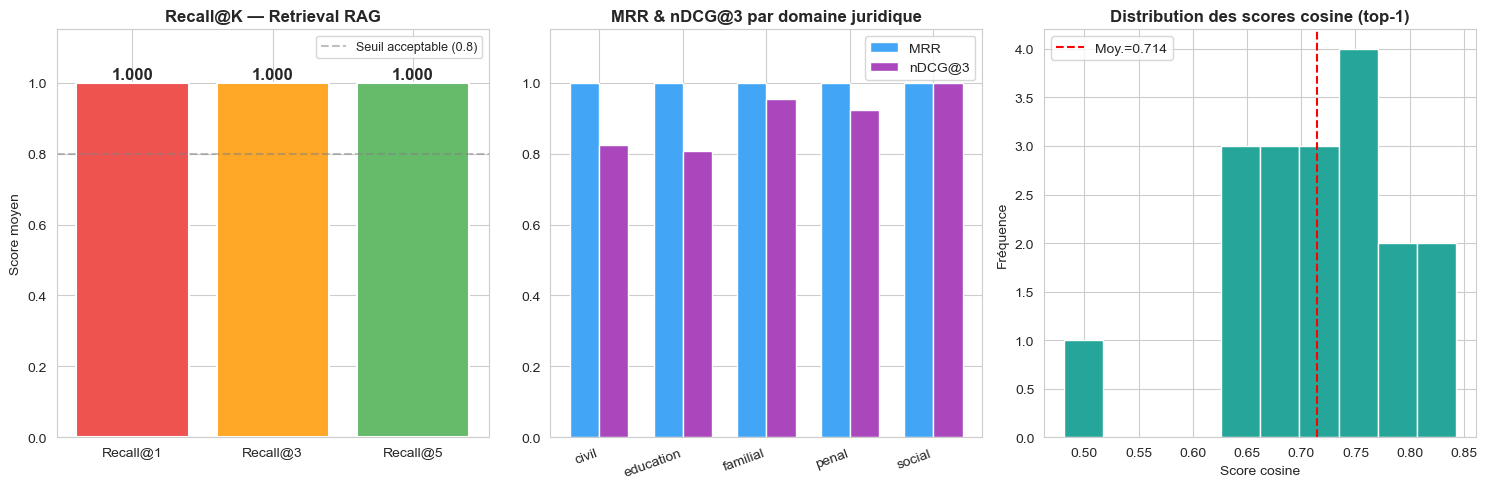

✅ Figure sauvegardée


In [20]:
# ============================================================
#  CELLULE 8 — Visualisation des métriques de retrieval
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Graphique 1 : Recall@K global ---
k_labels = ['Recall@1', 'Recall@3', 'Recall@5']
k_means  = [np.mean(all_scores[k.lower()]) for k in k_labels]
colors   = ['#EF5350', '#FFA726', '#66BB6A']
bars = axes[0].bar(k_labels, k_means, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, k_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Recall@K — Retrieval RAG', fontweight='bold')
axes[0].set_ylabel('Score moyen')
axes[0].axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Seuil acceptable (0.8)')
axes[0].legend(fontsize=9)

# --- Graphique 2 : MRR et nDCG par catégorie ---
cat_metrics = {}
for (query, cat, _), mrr_v, ndcg_v in zip(
    EVAL_QUERIES,
    all_scores['mrr'],
    all_scores['ndcg@3']
):
    if cat not in cat_metrics:
        cat_metrics[cat] = {'mrr': [], 'ndcg3': []}
    cat_metrics[cat]['mrr'].append(mrr_v)
    cat_metrics[cat]['ndcg3'].append(ndcg_v)

cats_u = sorted(cat_metrics.keys())
mrr_by_cat  = [np.mean(cat_metrics[c]['mrr'])   for c in cats_u]
ndcg_by_cat = [np.mean(cat_metrics[c]['ndcg3']) for c in cats_u]

x = np.arange(len(cats_u))
w = 0.35
axes[1].bar(x - w/2, mrr_by_cat,  w, label='MRR',    color='#42A5F5')
axes[1].bar(x + w/2, ndcg_by_cat, w, label='nDCG@3', color='#AB47BC')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats_u, rotation=20, ha='right')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('MRR & nDCG@3 par domaine juridique', fontweight='bold')
axes[1].legend()

# --- Graphique 3 : Distribution des scores de similarité top-1 ---
top1_scores = []
for query, _, _ in EVAL_QUERIES:
    q_emb = model.encode([query], normalize_embeddings=True).astype(np.float32)
    dists, _ = index.search(q_emb, 1)
    top1_scores.append(float(dists[0][0]))

axes[2].hist(top1_scores, bins=10, color='#26A69A', edgecolor='white')
axes[2].axvline(np.mean(top1_scores), color='red', linestyle='--',
                label=f'Moy.={np.mean(top1_scores):.3f}')
axes[2].set_title('Distribution des scores cosine (top-1)', fontweight='bold')
axes[2].set_xlabel('Score cosine')
axes[2].set_ylabel('Fréquence')
axes[2].legend()

plt.tight_layout()
plt.savefig('../processed_data/fig_retrieval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée')

⚙️  Calcul t-SNE (perplexity adaptée au nb d'articles)...


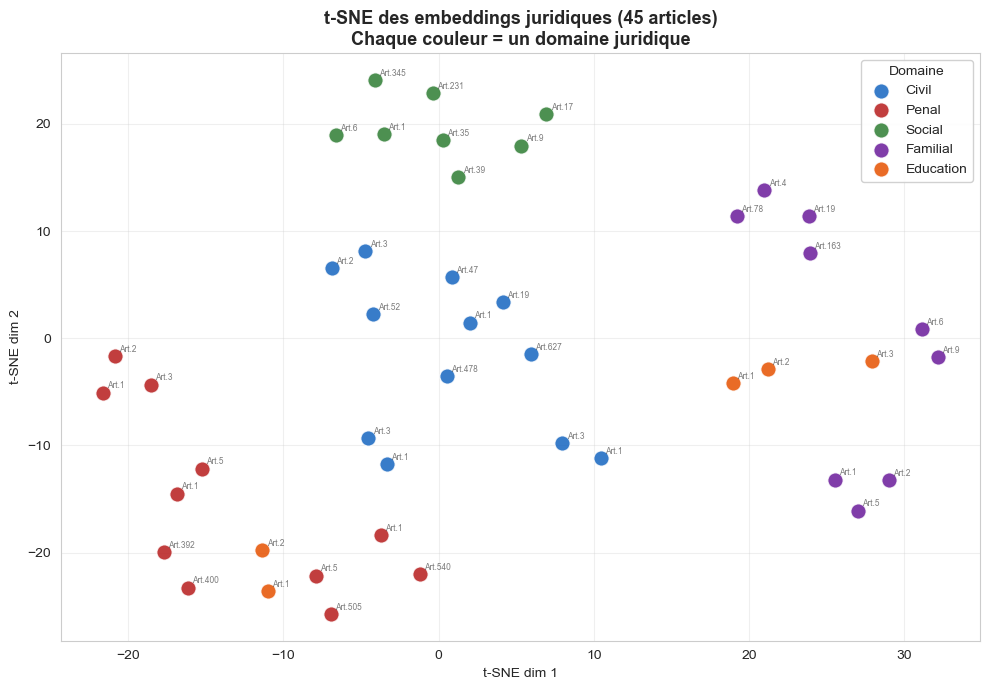

✅ t-SNE sauvegardée


In [21]:
# ============================================================
#  CELLULE 9 — Visualisation t-SNE de l'espace vectoriel
#
#  Vérification visuelle : les articles de même catégorie
#  doivent former des clusters distincts.
# ============================================================
from sklearn.manifold import TSNE

print('⚙️  Calcul t-SNE (perplexity adaptée au nb d\'articles)...')

n_samples    = len(embeddings)
perplexity   = min(10, n_samples - 1)   # perplexity < n_samples obligatoire

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    n_iter=1000
)
emb_2d = tsne.fit_transform(embeddings)

# Palette par catégorie
cat_colors = {
    'civil':     '#1565C0',
    'penal':     '#B71C1C',
    'social':    '#2E7D32',
    'familial':  '#6A1B9A',
    'education': '#E65100',
}

fig, ax = plt.subplots(figsize=(10, 7))
categories = df['category'].tolist()

for cat, color in cat_colors.items():
    mask = [i for i, c in enumerate(categories) if c == cat]
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=color, label=cat.capitalize(), s=120,
        alpha=0.85, edgecolors='white', linewidth=0.8
    )
    # Annoter les points
    for idx in mask:
        art_num = df.iloc[idx]['article_number']
        ax.annotate(
            f'Art.{art_num}',
            (emb_2d[idx, 0], emb_2d[idx, 1]),
            fontsize=6, alpha=0.6,
            xytext=(3, 3), textcoords='offset points'
        )

ax.set_title(
    f't-SNE des embeddings juridiques ({n_samples} articles)\n'
    'Chaque couleur = un domaine juridique',
    fontweight='bold', fontsize=13
)
ax.legend(title='Domaine', loc='best', framealpha=0.9)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../processed_data/fig_tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ t-SNE sauvegardée')

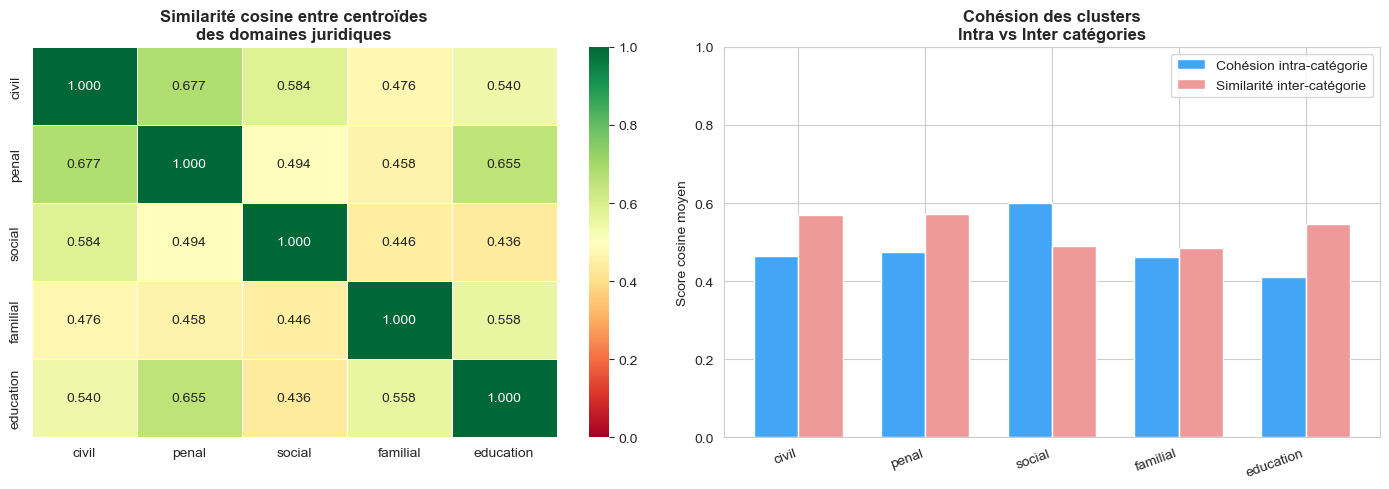

In [22]:
# ============================================================
#  CELLULE 10 — Matrice de similarité cosine inter-catégories
#
#  Une bonne représentation = similarité élevée intra-catégorie,
#  faible inter-catégorie.
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity

# Centroïdes par catégorie
cats_order = ['civil', 'penal', 'social', 'familial', 'education']
centroids  = []
for cat in cats_order:
    mask = df['category'] == cat
    centroid = embeddings[mask.values].mean(axis=0)
    centroid /= np.linalg.norm(centroid)   # re-normaliser
    centroids.append(centroid)

centroids = np.array(centroids)
sim_matrix = cosine_similarity(centroids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap similarité
mask_diag = np.zeros_like(sim_matrix, dtype=bool)
np.fill_diagonal(mask_diag, True)
sns.heatmap(
    sim_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
    xticklabels=cats_order, yticklabels=cats_order,
    vmin=0, vmax=1, ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Similarité cosine entre centroïdes\ndes domaines juridiques', fontweight='bold')

# Cohésion intra-catégorie vs distance inter-catégorie
intra_scores = []
inter_scores = []

for i, cat in enumerate(cats_order):
    mask = df['category'] == cat
    cat_embs = embeddings[mask.values]

    if len(cat_embs) > 1:
        sim_intra = cosine_similarity(cat_embs)
        # Exclure la diagonale (auto-similarité = 1)
        n = len(cat_embs)
        mean_intra = (sim_intra.sum() - n) / (n * (n - 1)) if n > 1 else 1.0
        intra_scores.append(mean_intra)

    # Score inter : similarité avec les autres centroïdes
    other_sims = [sim_matrix[i, j] for j in range(len(cats_order)) if j != i]
    inter_scores.append(np.mean(other_sims))

x = np.arange(len(cats_order))
w = 0.35
axes[1].bar(x - w/2, intra_scores, w, label='Cohésion intra-catégorie', color='#42A5F5')
axes[1].bar(x + w/2, inter_scores, w, label='Similarité inter-catégorie', color='#EF9A9A')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats_order, rotation=20, ha='right')
axes[1].set_ylim(0, 1)
axes[1].set_title('Cohésion des clusters\nIntra vs Inter catégories', fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('Score cosine moyen')

plt.tight_layout()
plt.savefig('../processed_data/fig_cluster_cohesion.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ============================================================
#  CELLULE 11 — Test de requêtes réelles
# ============================================================
TEST_CASES = [
    ('Mon employeur veut me licencier sans raison valable, que puis-je faire ?', 'fr'),
    ("J'ai été victime de violences physiques. Quels sont mes droits ?",         'fr'),
    ('Je veux acheter un appartement. Quelles règles s\'appliquent ?',           'fr'),
    ('أريد معرفة حقوقي كعامل في حالة الفصل التعسفي من العمل',                   'ar'),
]

print('🔍 TESTS DE RETRIEVAL\n' + '='*65)

for query, lang in TEST_CASES:
    q_emb = model.encode([query], normalize_embeddings=True).astype(np.float32)
    dists, idxs = index.search(q_emb, 3)

    print(f'\n[{lang.upper()}] {query[:65]}...' if len(query) > 65 else f'\n[{lang.upper()}] {query}')
    for rank, (dist, idx) in enumerate(zip(dists[0], idxs[0]), 1):
        if idx >= 0:
            m = metadata[idx]
            print(f'  #{rank} [{dist:.3f}] {m["title"][:45]} — '
                  f'Art.{m["article_number"]} ({m["category"]})')

🔍 TESTS DE RETRIEVAL

[FR] Mon employeur veut me licencier sans raison valable, que puis-je ...
  #1 [0.555] Code du Travail — Art.35 (social)
  #2 [0.534] Code du Travail — Art.39 (social)
  #3 [0.504] Conditions de travail des femmes — Art.17 (social)

[FR] J'ai été victime de violences physiques. Quels sont mes droits ?
  #1 [0.632] Loi relative à la lutte contre les violences  — Art.3 (penal)
  #2 [0.531] Loi relative à la lutte contre les violences  — Art.2 (penal)
  #3 [0.491] Loi relative à la lutte contre les violences  — Art.1 (penal)

[FR] Je veux acheter un appartement. Quelles règles s'appliquent ?
  #1 [0.426] Code des Obligations et des Contrats — Art.478 (civil)
  #2 [0.359] Code des Obligations et des Contrats — Art.19 (civil)
  #3 [0.327] Code des Obligations et des Contrats — Art.1 (civil)

[AR] أريد معرفة حقوقي كعامل في حالة الفصل التعسفي من العمل
  #1 [0.561] Code du Travail — Art.39 (social)
  #2 [0.459] Code du Travail — Art.35 (social)
  #3 [0.453] Code du Travai

In [24]:
# ============================================================
#  CELLULE 12 — Résumé final
# ============================================================
print('\n' + '='*60)
print('RÉSUMÉ FINAL — INDEX FAISS')
print('='*60)
print(f'Modèle d\'embedding : {MODEL_NAME}')
print(f'Dimension          : {embeddings.shape[1]}')
print(f'Articles indexés   : {index.ntotal}')
print(f'Type d\'index       : IndexFlatIP (cosine exact)')
print()
print('MÉTRIQUES DE RETRIEVAL')
print('-'*40)
for metric, vals in all_scores.items():
    print(f'  {metric.upper():<14} : {np.mean(vals):.4f}')
print()
print('Fichiers générés :')
print('  vector_db/faiss_index.bin')
print('  vector_db/embeddings.npy')
print('  vector_db/metadata.pkl')
print('  processed_data/fig_retrieval_metrics.png')
print('  processed_data/fig_tsne_embeddings.png')
print('  processed_data/fig_cluster_cohesion.png')


RÉSUMÉ FINAL — INDEX FAISS
Modèle d'embedding : paraphrase-multilingual-MiniLM-L12-v2
Dimension          : 384
Articles indexés   : 45
Type d'index       : IndexFlatIP (cosine exact)

MÉTRIQUES DE RETRIEVAL
----------------------------------------
  RECALL@1       : 1.0000
  RECALL@3       : 1.0000
  RECALL@5       : 1.0000
  MRR            : 1.0000
  NDCG@3         : 0.9133
  NDCG@5         : 0.8725

Fichiers générés :
  vector_db/faiss_index.bin
  vector_db/embeddings.npy
  vector_db/metadata.pkl
  processed_data/fig_retrieval_metrics.png
  processed_data/fig_tsne_embeddings.png
  processed_data/fig_cluster_cohesion.png
